In [180]:
import os
import numpy as np
import time
import pandas as pd
from scipy import interpolate
import pickle
import sys
from astropy.io import ascii
from astropy.table import Table
from astropy import units as u
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm, ListedColormap

In [189]:
def Enquiry(HashTable, InfoDict, Band1, Band2, dT1, dT2, dMag=None, Color=None):
    if abs(dT1) > abs(dT1-dT2):
        dT1, dT2 = dT1-dT2, -dT2    
    Ind1 = InfoDict['BandPairs'].index(Band1+Band2)
    #index for where 1st filter is, 2nd index for 2nd filter
    dT1grid = InfoDict['dT1s'][ abs( dT1 - InfoDict['dT1s'] ).argmin() ]
    dT2grid = InfoDict['dT2s'][ abs( dT2 - InfoDict['dT2s'] ).argmin() ]
    
    TimePairGrid = np.array([ InfoDict['dT1s'][ abs( dT1 - InfoDict['dT1s'] ).argmin() ], InfoDict['dT2s'][ abs( dT2 - InfoDict['dT2s'] ).argmin() ] ])
    # above will need some difference to set limit on difference in times
    Ind2 = np.where( (np.array(InfoDict['TimePairs']) == TimePairGrid ).all(axis=1) )[0][0]
    Results = HashTable[Ind1, Ind2]

    if dMag == None:
        pass        
    elif dMag<InfoDict['BinMag'][0] or dMag>=InfoDict['BinMag'][-1]:
        raise ValueError('The value of dMag is out of boundary, the available interval is [{:.2f}, {:.2f}).'.format(InfoDict['BinMag'][0], InfoDict['BinMag'][-1]))        
    else:
        Results = Results[np.where( dMag >= InfoDict['BinMag'] )[0][-1]]       

    if Color == None:
        pass        
    elif Color<InfoDict['BinColor'][0] or Color>=InfoDict['BinColor'][-1]:
        raise ValueError('The value of Color is out of boundary, the available interval is [{:.2f}, {:.2f}).'.format(InfoDict['BinColor'][0], InfoDict['BinColor'][-1]))
        
    else:
        Results = Results[..., np.where( Color >= InfoDict['BinColor'] )[0][-1] ]

    return Results

In [47]:
def loadCubeFile(FilePath):
    
    FileTime = FilePath[FilePath.find('Cube_')+4: FilePath.rfind('__')]
    
    with open(FilePath, 'rb') as f:
        InfoDict = pickle.load(f)
        print(InfoDict)
        HashTable = pickle.load(f)
    
    dT1Range = [InfoDict['dT1s'][0], InfoDict['dT1s'][-1]]
    dT2Range = [InfoDict['dT2s'][0], InfoDict['dT2s'][-1]]    
    dT1step = ( InfoDict['dT1s'][1:] - InfoDict['dT1s'][:-1] ).min()
    dT2step = ( InfoDict['dT2s'][1:] - InfoDict['dT2s'][:-1] ).min()
        
    StartObjNo = 'n/a'
    
    if 'StartObjNo' in InfoDict:
        StartObjNo = InfoDict['StartObjNo']
        
   # print('{:<35}ObjectNo: {:>5}, start at {:>3}. dT1 range = {}, step = {:>3}. dT2 range = {}, step = {:>3}. BandpairNo: {}.'.format(
   #     InfoDict['EventNames']+FileTime, InfoDict['ObjectNo'], StartObjNo, dT1Range, dT1step, dT2Range, dT2step, len(InfoDict['BandPairs'])))

    # InfoDict['OutliersRatio'] = InfoDict['Outliers'] / HashTable.sum()

    if 'Outliers' in InfoDict:
        print('\t{} outliers found, the ratio to the max value is {:.12f}.'.format(InfoDict['Outliers'], InfoDict['OutliersRatio']) )
        print('\tdMag range is {}, \n\tColor range is {}.'.format( InfoDict['dMagRange'], InfoDict['ColorRange'] ) )

    if 'Overflow' in InfoDict:
        print('\tData in the HashTable overflowed, the minimun value is {}.'.format(InfoDict['Overflow']))
        
    return InfoDict, HashTable;

In [48]:
def PlotSlice(HashTable1, InfoDict1, Band1, Band2, dT1, dT2, ax = None):
    # cut_gist_heat = ListedColormap(plt.colormaps["gist_heat"](np.linspace(0, 0.9, 256)))
    
    if ax == None: 
        fig, ax = plt.subplots(1,1)

    

    Map1 = Enquiry(HashTable1, InfoDict1, Band1, Band2, dT1, dT2) * 10000000

    ax.pcolor(InfoDict['BinMag'], InfoDict['BinColor'], np.transpose(Map1)+1,
                        norm=LogNorm(1, vmax=Map1.max()+1), cmap="gist_grey")

        # ax.scatter(Data[0], Data[1], c='mediumpurple', s=1, alpha=0.1, )


    ax.set_xlim([-1.5, 2])
    ax.set_ylim([-5, 8]) 


In [49]:
def PlotSliceWithTwoHists(HashTable1, InfoDict1, HashTable2, InfoDict2, Band1, Band2, dT1, dT2, ax = None):
    cut_gist_heat = ListedColormap(plt.colormaps["gist_heat"](np.linspace(0, 0.9, 256)))
    
    if ax == None: 
        fig, ax = plt.subplots(1,1)
    Map1 = Enquiry(HashTable1, InfoDict1, Band1, Band2, dT1, dT2) * 10000000
    Map2 = Enquiry(HashTable2, InfoDict2, Band1, Band2, dT1, dT2) * 10000000
    
    ax.pcolor(InfoDict['BinMag'], InfoDict['BinColor'], np.transpose(Map1)+1,
                       norm=LogNorm(1, vmax=Map1.max()+1), cmap='gist_gray')
    ax.pcolor(InfoDict2['BinMag'], InfoDict2['BinColor'], np.transpose(Map2),
                       norm=LogNorm(1, vmax=Map2.max()-1), cmap=cut_gist_heat)
            
    ax.set_xlim([-1.5, 2])
    ax.set_ylim([-5, 8]) 

In [149]:
dp2 = ascii.read("/lustre/lrspec/users/4300/cube/Data/Phot/DP2query3.ecsv")

In [150]:
dp2.info

<Table length=4208>
     name       dtype  unit                                                description                                               
-------------- ------- ---- ---------------------------------------------------------------------------------------------------------
   diaObjectId   int64                                             Id of the DiaObject that this DiaForcedSource was associated with.
          band    str1                                            Abstract filter that is not associated with a particular instrument
       psfFlux float32  nJy                              Flux derived from linear least-squares fit of psf model forced on the calexp
    psfFluxErr float32  nJy           Uncertainty on the flux derived from linear least-squares fit of psf model forced on the calexp
   psfDiffFlux float32  nJy                    Flux derived from linear least-squares fit of psf model forced on the image difference
psfDiffFluxErr float32  nJy Uncertainty on

In [151]:
len(dp2[dp2["psfFlux"]>0])

4208

In [152]:
dp2 = dp2[dp2["psfFlux"]>0]

In [153]:
len(np.unique(dp2["diaObjectId"]))

63

In [154]:
sel_objs = np.unique(dp2["diaObjectId"])[0:100]
dp2_sel = dp2[np.isin(dp2["diaObjectId"],sel_objs)]

In [155]:
# pref_dT1s = np.arange(-480, 481, 15)
# pref_dT2s = np.hstack(( np.arange(-1920, -1439, 30), np.arange(-480, 481, 30), np.arange(1440, 1921, 30) )) 
pref_dT1s = np.arange(-480, 481, 1)
pref_dT2s = np.hstack((np.arange(-480, 481, 1))) 
thrs = {'u': 23.9, 'g': 25.0, 'r': 24.7, 'i': 24.0, 'z': 23.3, 'y': 22.1}

In [156]:
obj_dfs = []

for n, obj in enumerate(np.unique(dp2_sel["diaObjectId"])):
    timepairs = []
    bandpairs = []
    dMags = []
    colors = []
    name = []
    dp2_obj = dp2_sel[dp2_sel["diaObjectId"] == obj]
    
    for i,mjd1 in enumerate(dp2_obj["expMidptMJD"]):
        dT1s2 = []
        dT2s2 = []
        dMs = []
        bps = []
        cs = []
        for j, mjd2 in enumerate(dp2_obj["expMidptMJD"]):
            if dp2_obj["band"][i] != dp2_obj["band"][j]:
                dT1 = -(mjd1-mjd2)*u.day
                dT1 = int((dT1.to(u.min)/u.min))

                
                if dT1 in pref_dT1s:
                    M1 = -2.5*np.log10(dp2_obj["psfFlux"][i])+31.4
                    M2 = -2.5*np.log10(dp2_obj["psfFlux"][j])+31.4
                    color = M1-M2
                    #= dp1_obj["psfFlux"][i] / dp1_obj["psfFlux"][j]
                    BandPair = dp2_obj["band"][i]+dp2_obj["band"][j]
                        
                    
                    dT1s2.append(dT1)
                    cs.append(color)
                    bps.append(BandPair)
            
            else:
                dT2 = -(mjd1-mjd2)*u.day
                dT2 = int((dT2.to(u.min)/u.min))

                
                if dT2 in pref_dT2s and dT2 != 0:
                    M1 = -2.5*np.log10(dp2_obj["psfFlux"][i])+31.4
                    M2 = -2.5*np.log10(dp2_obj["psfFlux"][j])+31.4
                    
                    # dflux = (dp1_obj["psfFlux"][i] / dp1_obj["psfFlux"][j])
    
                    dT2s2.append(dT2)
                    #dMs.append((-2.5*np.log10(dflux))*np.sign(dT2))
                    dMs.append((M1-M2)*np.sign(dT2))
            
        for k, dT1 in enumerate(dT1s2):
            for h, dT2 in enumerate(dT2s2):
                timepairs.append((dT1,dT2))

                bandpairs.append(bps[k])
                colors.append(cs[k])
                
                dMags.append(dMs[h])

                name.append(obj)
                    

    obj_pts = pd.DataFrame()
    obj_pts["Timepairs"] = timepairs
    obj_pts["dMags"] = dMags
    obj_pts["Colors"] = colors
    obj_pts["Bandpairs"] = bandpairs
    obj_pts["Object Name"] = name

    obj_dfs.append(obj_pts)

    print(f'{n+1} of {len(np.unique(dp2_sel["diaObjectId"]))}')
print("Done!")

1 of 63
2 of 63
3 of 63
4 of 63
5 of 63
6 of 63
7 of 63
8 of 63
9 of 63
10 of 63
11 of 63
12 of 63
13 of 63
14 of 63
15 of 63
16 of 63
17 of 63
18 of 63
19 of 63
20 of 63
21 of 63
22 of 63
23 of 63
24 of 63
25 of 63
26 of 63
27 of 63
28 of 63
29 of 63
30 of 63
31 of 63
32 of 63
33 of 63
34 of 63
35 of 63
36 of 63
37 of 63
38 of 63
39 of 63
40 of 63
41 of 63
42 of 63
43 of 63
44 of 63
45 of 63
46 of 63
47 of 63
48 of 63
49 of 63
50 of 63
51 of 63
52 of 63
53 of 63
54 of 63
55 of 63
56 of 63
57 of 63
58 of 63
59 of 63
60 of 63
61 of 63
62 of 63
63 of 63
Done!


In [160]:
print(obj_dfs[1]["Timepairs"])
print(obj_dfs[1]["Bandpairs"])

0     (-42, -17)
1      (24, -17)
2      (19, -17)
3      (27, -17)
4       (17, -5)
         ...    
83       (27, 1)
84     (-28, -6)
85      (-28, 1)
86      (25, -6)
87       (25, 1)
Name: Timepairs, Length: 88, dtype: object
0     iz
1     iz
2     iz
3     iz
4     yi
      ..
83    iz
84    iy
85    iy
86    iz
87    iz
Name: Bandpairs, Length: 88, dtype: object


In [138]:
print(obj_dfs[0]["Timepairs"].str[0])

0       -9
1       -9
2       -9
3      -10
4      -10
        ..
6863   -10
6864    -8
6865    -7
6866    41
6867   -11
Name: Timepairs, Length: 6868, dtype: int64


(array([  2.,   0.,   0., 160., 781., 781., 160.,   0.,   0.,   2.]),
 array([-223. , -178.4, -133.8,  -89.2,  -44.6,    0. ,   44.6,   89.2,
         133.8,  178.4,  223. ]),
 <BarContainer object of 10 artists>)

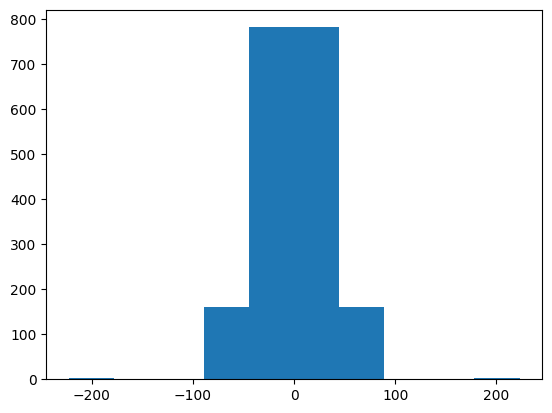

In [162]:
plt.hist(obj_dfs[4]["Timepairs"].str[1])

(array([  9., 100.,  60.,   0.,   0.,   0.,   0.,   0.,   1.,   1.]),
 array([ 25. ,  44.8,  64.6,  84.4, 104.2, 124. , 143.8, 163.6, 183.4,
        203.2, 223. ]),
 <BarContainer object of 10 artists>)

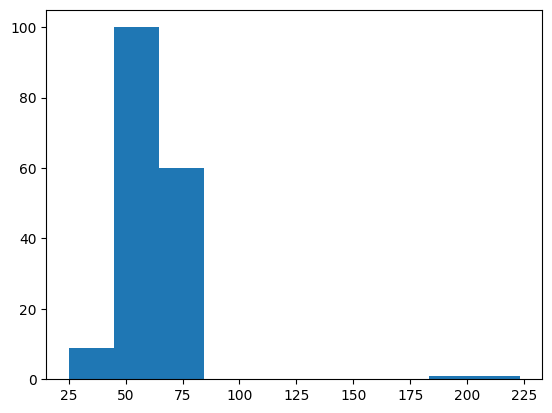

In [163]:
checkycheck = obj_dfs[0]["Timepairs"].str[1][obj_dfs[0]["Timepairs"].str[1] > 20]
plt.hist(checkycheck)

In [183]:
EventNames = ['AGN', 'CART', 'EB', 'ILOT', 'KN_B19', 'KN_K17', 'MIRA', 'Mdwarf',
              'PISN', 'RRL', 'SLSN-I', 'SNII-NMF', 
              #'SNII-Templates', 
              'SNIIn',
              'SNIa-91bg', 'SNIa-SALT2', 'SNIax', 'SNIbc-MOSFIT',
              #'SNIbc-Templates', 
              'TDE', 'V19_CC+HostXT', 'uLens-Binary',
              #'uLens-Single-GenLens', 
              #'uLens-Single_PyLIMA'
             ]


In [184]:
PathCubeFolder = '/lustre/lrspec/users/4300/cube/Data/Datacube/All_Events'
CubeFileNames = os.listdir(PathCubeFolder)
CubeFileNames = [ ii for ii in CubeFileNames if '.pkl' in ii and "211_223" in ii]

In [185]:
CubeFileNames

['211_223_ProbCube_0806_1540__SLSN-I.pkl',
 '211_223_ProbCube_0806_1526__MIRA.pkl',
 '211_223_ProbCube_0806_1605__TDE.pkl',
 '211_223_ProbCube_0806_1615__uLens-Single_PyLIMA.pkl',
 '211_223_ProbCube_0806_1521__EB.pkl',
 '211_223_ProbCube_0806_1548__SNIIn.pkl',
 '211_223_ProbCube_0806_1613__uLens-Single-GenLens.pkl',
 '211_223_ProbCube_0806_1532__KN_B19.pkl',
 '211_223_ProbCube_0806_1537__RRL.pkl',
 '211_223_ProbCube_0806_1546__SNII-Templates.pkl',
 '211_223_ProbCube_0806_1557__SNIax.pkl',
 '211_223_ProbCube_0806_1534__PISN.pkl',
 '211_223_ProbCube_0806_1602__SNIbc-Templates.pkl',
 '211_223_ProbCube_0806_1543__SNII-NMF.pkl',
 '211_223_ProbCube_0806_1529__Mdwarf.pkl',
 '211_223_ProbCube_0806_1515__AGN.pkl',
 '211_223_ProbCube_0806_1518__CART.pkl',
 '211_223_ProbCube_0806_1610__uLens-Binary.pkl',
 '211_223_ProbCube_0806_1608__V19_CC+HostXT.pkl',
 '211_223_ProbCube_0806_1554__SNIa-SALT2.pkl',
 '211_223_ProbCube_0806_1551__SNIa-91bg.pkl',
 '211_223_ProbCube_0806_1524__ILOT.pkl',
 '211_223_P

In [186]:
mp_colors = ["red", "orange", "yellow", "green","pink", "blue", "violet"]
mp_shapes = ["s","D","*","^","<","v","P"]
sizes = [7, 7, 11, 8, 8, 8, 9]
cut_gist_heat = ListedColormap(plt.colormaps["gist_heat"](np.linspace(0, 0.9, 256)))

In [228]:
bandpairs = ["ir","gr"]
timepairs = [(-12,-223),(33,-189)]
# Band1 = 'r'
# Band2 = 'g'
# dT1 = 45
# dT2 = 1440


Space = 0.05
ColNo = 3
RowNo = 6

fig, axs = plt.subplots(RowNo, ColNo, figsize = (18, 4*RowNo), sharex=True, sharey=True, dpi = 750)
fig.subplots_adjust(hspace=Space, wspace=Space)
axsflat = axs.flatten()

q = 1
ii=0

obj_dfs_filt = [obj_df for obj_df in obj_dfs if (len(obj_df[obj_df["Timepairs"]==timepairs[q]][obj_df["Bandpairs"]==bandpairs[q]]) > 0)]

for EventName in EventNames:
    
    print('|', end='')

    if EventName == 'V19_CC+HostXT'or 'KN_K' in EventName:
        continue
    for CubeFileName in CubeFileNames:
        if EventName in CubeFileName:
            break
            
    CubeFilePath = os.path.join(PathCubeFolder, CubeFileName)

    with open(CubeFilePath, 'rb') as f:
        InfoDict = pickle.load(f)
        Cube = pickle.load(f)
        
    CubeNorm = Cube / Cube.max(-1, keepdims=True).max(-2, keepdims=True)
    np.nan_to_num(CubeNorm, copy=False);
    
    Map = Enquiry(CubeNorm, InfoDict, bandpairs[q][0], bandpairs[q][1], timepairs[q][0], timepairs[q][1]) 
    
    Map = Map*100000

    
    axsflat[ii].pcolor(InfoDict['BinMag'], InfoDict['BinColor'], np.transpose(Map)+1,
                      norm=LogNorm(1, vmax=Map.max()+1), cmap='gist_gray')

    if EventName == 'SNIa-SALT2':
        CAATPath = "/lustre/lrspec/users/4300/cube/Data/Datacube/CAAT/SweetSpot/ProbCube_0626_1050__Neg_CAATSNIa.pkl"
        with open(CAATPath, 'rb') as f:
            InfoDict2 = pickle.load(f)
            Cube2 = pickle.load(f)
                
        CubeNorm2 = Cube2 / Cube2.max(-1, keepdims=True).max(-2, keepdims=True)
        np.nan_to_num(CubeNorm2, copy=False);
        
        Map2 = Enquiry(CubeNorm2, InfoDict2, bandpairs[q][0], bandpairs[q][1], timepairs[q][0], timepairs[q][1])    
        
        Map2 = Map2*100000
        
        axsflat[ii].pcolor(InfoDict2['BinMag'], InfoDict2['BinColor'], np.transpose(Map2),
                   norm=LogNorm(1, vmax=Map2.max()-1), cmap=cut_gist_heat, alpha = 0.7)

    for k, obj_pts in enumerate(obj_dfs_filt[10:20]):
        # axsflat[ii].plot(list(obj_pts["dMags"][obj_pts["Bandpairs"]== bandpairs[q]][obj_pts["Timepairs"]==timepairs[q]]),
        #                list(obj_pts["Colors"][obj_pts["Bandpairs"]== bandpairs[q]][obj_pts["Timepairs"]==timepairs[q]]), 
        #                mp_shapes[k], mec = "black", 
        #                  mew = 0.7, color = "#00dcbbff", ms = sizes[k])
        axsflat[ii].plot(list(obj_pts["dMags"][obj_pts["Bandpairs"]== bandpairs[q]][obj_pts["Timepairs"]==timepairs[q]]),
                       list(obj_pts["Colors"][obj_pts["Bandpairs"]== bandpairs[q]][obj_pts["Timepairs"]==timepairs[q]]), 
                       "o", mec = "black", 
                         mew = 0.7, label = obj_pts["Object Name"][0])


    
    axsflat[ii].text(0.95, 0.95, EventName, c='w', ha='right', va='top', transform=axsflat[ii].transAxes, size = "x-large")
    axsflat[17].legend(loc = "center")
    if ii%3 == 0:
        axsflat[ii].set_ylabel(f"{bandpairs[q][0]} - {bandpairs[q][1]}", size = "x-large")
    if ii in [18,19,20]:
        axsflat[ii].set_xlabel(f"$\\Delta$ {bandpairs[q][0]}", size = "x-large")
        
    ii += 1
        
axs[0,0].set_xlim([-1.5, 2])
axs[0,0].set_ylim([-5, 5])

#fig.suptitle(f"$\\Delta T_1$ = {timepairs[q][0]} min, $\\Delta T_2$ = {timepairs[q][1]} min", x = 0.4, y = 0.8, size = 10)
title = f"$\\Delta T_1$ = {timepairs[q][0]} min, $\\Delta T_2$ = {timepairs[q][1]} min"
fig.suptitle(title, y = 0.89, size ="xx-large", color = "black")
#plt.savefig("/lustre/lrspec/users/4300/cube/Figures/DP2_comparison_33-189_gr")

/tmp/ipykernel_46108/1448877021.py:20: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  obj_dfs_filt = [obj_df for obj_df in obj_dfs if (len(obj_df[obj_df["Timepairs"]==timepairs[q]][obj_df["Bandpairs"]==bandpairs[q]]) > 0)]
/tmp/ipykernel_46108/1448877021.py:20: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  obj_dfs_filt = [obj_df for obj_df in obj_dfs if (len(obj_df[obj_df["Timepairs"]==timepairs[q]][obj_df["Bandpairs"]==bandpairs[q]]) > 0)]
/tmp/ipykernel_46108/1448877021.py:20: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  obj_dfs_filt = [obj_df for obj_df in obj_dfs if (len(obj_df[obj_df["Timepairs"]==timepairs[q]][obj_df["Bandpairs"]==bandpairs[q]]) > 0)]
/tmp/ipykernel_46108/1448877021.py:20: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  obj_dfs_filt = [obj_df for obj_df in obj_dfs if (len(obj_df[obj_df["Timepairs"]==timepairs[q]][obj_df["Bandpairs"]==bandp

|||||||

/tmp/ipykernel_46108/1448877021.py:78: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axsflat[17].legend(loc = "center")
/tmp/ipykernel_46108/1448877021.py:78: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axsflat[17].legend(loc = "center")
/tmp/ipykernel_46108/1448877021.py:78: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axsflat[17].legend(loc = "center")
/tmp/ipykernel_46108/1448877021.py:78: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axsflat[17].legend(loc = "center")
/tmp/ipykernel_4

||||||

/tmp/ipykernel_46108/1448877021.py:78: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axsflat[17].legend(loc = "center")
/tmp/ipykernel_46108/1448877021.py:78: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axsflat[17].legend(loc = "center")
/tmp/ipykernel_46108/1448877021.py:78: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axsflat[17].legend(loc = "center")


|||||||

/tmp/ipykernel_46108/1448877021.py:78: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axsflat[17].legend(loc = "center")
/tmp/ipykernel_46108/1448877021.py:78: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axsflat[17].legend(loc = "center")
/tmp/ipykernel_46108/1448877021.py:78: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axsflat[17].legend(loc = "center")
/tmp/ipykernel_46108/1448877021.py:78: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axsflat[17].legend(loc = "center")


Text(0.5, 0.89, '$\\Delta T_1$ = 33 min, $\\Delta T_2$ = -189 min')

In [198]:
obj_dfs[3]

,Timepairs,dMags,Colors,Bandpairs,Object Name
0,"(-30, -10)",2.509321,6.232037,iy,770576712688730490
1,"(-30, -14)",-3.756695,6.232037,iy,770576712688730490
2,"(-20, 10)",2.509321,8.741358,iy,770576712688730490
3,"(-20, -4)",-6.266016,8.741358,iy,770576712688730490
4,"(33, -189)",-0.876427,0.510532,gr,770576712688730490
5,"(223, 189)",-0.876427,-0.365894,gr,770576712688730490
6,"(-16, 14)",-3.756695,2.475342,iy,770576712688730490
7,"(-16, 4)",-6.266016,2.475342,iy,770576712688730490


In [218]:
dp2["ra"][dp2["diaObjectId"]==770576712688730839]

318.30845230541877
318.30845230541877
318.30845230541877
318.30845230541877
318.30845230541877
318.30845230541877
318.30845230541877
318.30845230541877
318.30845230541877
318.30845230541877
318.30845230541877


In [217]:
dp2["dec"][dp2["diaObjectId"]==770576712688730839]

-14.830596313633144
-14.830596313633144
-14.830596313633144
-14.830596313633144
-14.830596313633144
-14.830596313633144
-14.830596313633144
-14.830596313633144
-14.830596313633144
-14.830596313633144
-14.830596313633144


In [216]:
print(dp2["expMidptMJD"][dp2["diaObjectId"]==770576712688730839].max(),dp2["expMidptMJD"][dp2["diaObjectId"]==770576712688730839].min())

60940.14532325546 60831.299511606616
